# Quick Commerce (Q-Commerce) Platform Analysis
### Competitive Intelligence Across 8 Indian Delivery Platforms

---

**Author:** Jeshurun Nana Kojo Ansah  
**Dataset:** 1,000,000 synthetic orders across 8 Q-Commerce platforms (Swiggy Instamart, Blinkit, Zepto, Big Basket, Flipkart Minutes, Amazon Now, Dunzo, Jio Mart)  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly · SciPy · Scikit-learn

---

## Business Context

Quick Commerce is a hyper-competitive segment of e-commerce focused on ultra-fast delivery (typically under 30 minutes). In India, platforms like Blinkit, Zepto, and Swiggy Instamart are locked in intense competition on three dimensions: **revenue**, **delivery speed**, and **customer satisfaction**.

This analysis answers four core business questions:

| # | Question |
|---|----------|
| 1 | Which platforms generate the most revenue, and why? |
| 2 | Who are the customers, and what are they buying? |
| 3 | Which platforms are operationally fastest and most consistent? |
| 4 | Does offering discounts actually increase order value? |

---

## Key Findings (Executive Summary)

> **Swiggy Instamart leads in total revenue** — but the gap between all platforms is narrow (< 24%), indicating a highly competitive market with no dominant player.

> **Zepto leads on delivery speed** — recording the fastest average delivery time (9.6 min) and highest speed per km across all platforms in this dataset.

> **The 21–50 age band drives ~71% of all orders** across every platform. Teens (11–20) represent only ~7%, suggesting Q-Commerce skews toward working adults.

> **Gurgaon and Noida are the top revenue cities**, but all 10 major cities are within 17% of each other — indicating geographically even demand.

> **Discounted orders have ~42% higher average order value**. Discounts likely attract higher-basket customers, not just more orders.

> **Bulk buyers (high-value outlier orders) average ₹1,176 per order — 2.1× the standard customer.** 72.4% apply discounts vs 39.3% in the main dataset, identifying them as a high-intent, discount-dependent cohort currently served through standard consumer infrastructure.

> *All summary statistics above are computed dynamically in their respective sections below.*

> *See section 9 for a more comprehensive summary and recommendation.*

---
## 1. Environment Setup & Data Loading

In [1]:
# ───Import Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import MinMaxScaler
import warnings
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent/'src'))
from config import DATA_RAW, DATA_CLEAN, DATA_OUTLIERS, PLOTS_DIR

warnings.filterwarnings('ignore')

# ───Global Plot Style ──────────────────────────────────────────────────────────
sns.set_theme(style = 'whitegrid', palette = 'bright', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

# ───Currency formatter ──────────────────────────────────────────────────────────
rupee_fmt = ticker.FuncFormatter(lambda x, _: f'₹{int(x):,}')

print('Libraries loaded.')
print(f'Project root: {PLOTS_DIR.parent}')
print(f'Data path: {DATA_RAW}')
print(f'Plots dir: {PLOTS_DIR}')
assert DATA_RAW.exists(), f'Raw data not found at: {DATA_RAW}'
print('All paths resolved.')

Libraries loaded.
Project root: C:\Users\BRAIKE\Q-Commerce_Analysis_Project
Data path: C:\Users\BRAIKE\Q-Commerce_Analysis_Project\data\quick_commerce_data_raw.csv
Plots dir: C:\Users\BRAIKE\Q-Commerce_Analysis_Project\plots
All paths resolved.


In [2]:
#  ── Load Raw Data ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_RAW)
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head(3)

Shape: 1,000,000 rows x 13 columns


,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.3375,19.182,11.97,12.0,Dairy,Wallet,2.1,1,3.2
1,1000002,Flipkart Minutes,Amritsar,56,1007.3000,19.644,12.74,10.0,Snacks,Cash on Delivery,2.3,0,3.2
2,1000003,Flipkart Minutes,Mumbai,18,1211.6600,16.910,4.85,NaN,Personal Care,Cash on Delivery,3.3,0,3.8


---
## 2. Data Quality Assessment
Before cleaning, I audited the data set to understand its structure and completeness.

In [3]:
# Schema and Data types
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  str    
 2   City                     948000 non-null   str    
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  str    
 9   Payment_Method           1000000 non-null  str    
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), str(4)
memory usage: 99.2 MB


In [4]:
# Statistical profile of numeric columns
df_raw.describe(include = 'number').round(2)

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,965000.00,953000.00,1000000.00,895863.00
mean,1500000.50,38.47,571.64,16.45,7.75,10.00,3.04,0.40,3.75
std,288675.28,12.12,382.78,6.26,4.19,5.48,1.19,0.49,0.72
min,1000001.00,18.00,50.00,5.00,0.50,1.00,1.00,0.00,2.50
25%,1250000.75,28.00,287.84,12.37,4.13,5.00,2.00,0.00,3.10
50%,1500000.50,38.00,531.32,16.34,7.74,10.00,3.00,0.00,3.70
75%,1750000.25,49.00,796.18,20.20,11.38,15.00,4.00,1.00,4.40
max,2000000.00,59.00,13877.32,40.00,15.00,19.00,5.00,1.00,5.00


In [5]:
# Duplicate check
n_duplicates = df_raw.duplicated().sum()
print(f'Duplicated rows: {n_duplicates:,}')

Duplicated rows: 0


In [6]:
# Null value Audit
null_count = df_raw.isna().sum()
null_pct   = (null_count/len(df_raw)*100).round(2)

null_report = pd.DataFrame({
    'Null Count': null_count,
    '% Missing': null_pct,
    'Action': ''
})
null_report.loc['City',                    'Action'] = "Fill with 'Other' — unknown city, not missing data"
null_report.loc['Items_Count',             'Action'] = "Drop rows — cannot impute order size"
null_report.loc['Customer_Rating',         'Action'] = "Group-median impute by Company"
null_report.loc['Delivery_Partner_Rating', 'Action'] = "Group-mean impute by Company"

print('Missing Value Audit:')
null_report[null_report['Null Count'] > 0]

Missing Value Audit:


,Null Count,% Missing,Action
City,52000,5.20,"Fill with 'Other' — unknown city, not missing ..."
Items_Count,35000,3.50,Drop rows — cannot impute order size
Customer_Rating,47000,4.70,Group-median impute by Company
Delivery_Partner_Rating,104137,10.41,Group-mean impute by Company


---
## 3. Data Cleaning
Every transformation is justified by the audit above. I worked on a copy of the raw data.

In [7]:
df = df_raw.copy()

# ─── 3.1 City nulls ➡ Other ────────────────────────────────────────────────────────── 
# These 52000 rows (~ 5.20%) have no city recorded but are otherwise complete.
# Dropping them would render the city-level analysis bias. Therefore, I filled them with "Other".
df['City'] = df['City'].fillna('Other')

# ── 3.2  Items_Count nulls → drop ───────────────────────────────────────────
# Order size is a core metric; imputing it would fabricate data.
df = df.dropna(subset = ['Items_Count']).reset_index(drop=True)
print(f'Rows after dropping null Items_Count: {len(df):,}')

Rows after dropping null Items_Count: 965,000


In [8]:
# ── 3.3  Customer_Rating → group-median impute by Company ───────────────────
# Rationale: Ratings vary meaningfully across platforms (see medians below).
# Using the platform's own median preserves that differentiation.
print('Per-company Customer_Rating medians:')
print(df.groupby('Company')['Customer_Rating'].median().to_string())

df['Customer_Rating'] = df.groupby('Company')['Customer_Rating'].transform(lambda x : x.fillna(x.median()))

print(f"\nCustomer_Rating nulls remaining: {df['Customer_Rating'].isna().sum()}")

Per-company Customer_Rating medians:
Company
Amazon Now          2.9
Big Basket          3.1
Blinkit             3.6
Dunzo               2.4
Flipkart Minutes    3.0
Jio Mart            2.8
Swiggy Instamart    3.3
Zepto               3.2

Customer_Rating nulls remaining: 0


In [9]:
# ── 3.4  Delivery_Partner_Rating → group-mean impute by Company ─────────────
# Verification: missing ratings have virtually the same average delivery time
# as rated ones — so missingness is random, not linked to performance.
print('Delivery time — rated vs unrated partners:')
display(
    df.groupby(df['Delivery_Partner_Rating'].isna())['Delivery_Time_Min']
    .mean()
    .rename(index={False: 'Has Rating', True: 'Missing Rating'})
    .reset_index()
    .rename(columns={'Delivery_Partner_Rating': 'Has_Missing_Rating',
                     'Delivery_Time_Min': 'Avg_Delivery_Time_Min'})
)

df['Delivery_Partner_Rating'] = (
    df.groupby('Company')['Delivery_Partner_Rating']
    .transform(lambda x : x.fillna(x.mean()))
)

# Safety net: if any company had 100% nulls (none here), fall back to global mean
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].fillna(df['Delivery_Partner_Rating'].mean())

print(f"\nDelivery_Partner_Rating nulls remaining: {df['Delivery_Partner_Rating'].isnull().sum()}")

Delivery time — rated vs unrated partners:


,Has_Missing_Rating,Avg_Delivery_Time_Min
0,Has Rating,16.452975
1,Missing Rating,16.442831



Delivery_Partner_Rating nulls remaining: 0


In [10]:
# ── 3.5 Final null check ────────────────────────────────────────────────────
assert df.isna().sum().sum() == 0, "Nulls still present — review above steps"
print('No nulls remaining.')

No nulls remaining.


In [11]:
# ── 3.6  Data type corrections ───────────────────────────────────────────────
df['Order_ID'] = df['Order_ID'].astype(str)

# Round continuous measurements to sensible precision, then cast to integer
# where the business meaning is whole units (minutes, items, ratings on 1-5 scale)
df['Order_Value'] = df['Order_Value'].round(0).astype(int)
df['Delivery_Time_Min'] = df['Delivery_Time_Min'].round(0).astype(int)
df['Distance_Km'] = df['Distance_Km'].round(1)
df['Items_Count'] = df['Items_Count'].astype(int)
df['Customer_Rating'] = df['Customer_Rating'].round(0).astype(int)
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].round(0).astype(int)

print('Updated dtypes:')
print(df.dtypes)

Updated dtypes:
Order_ID                       str
Company                        str
City                           str
Customer_Age                 int64
Order_Value                  int64
Delivery_Time_Min            int64
Distance_Km                float64
Items_Count                  int64
Product_Category               str
Payment_Method                 str
Customer_Rating              int64
Discount_Applied             int64
Delivery_Partner_Rating      int64
dtype: object


---
## 4. Outlier Detection & Treatment
I applied IQR detection only to **continuous business metrics**  — `Order_Value`, `Delivery_Time_Min`, `Distance_Km` and `Items_Count`.

**Rating columns (`Customer_Rating`, `Delivery_Partner_Rating`) and `Customer_Age` are explicitly excluded:**
- Ratings are bounded 1–5 by design; an IQR fence on a bounded scale is meaningless.
- Age has no business rationale for exclusion within the plausible range.

In [12]:
# ── Interquartile Range Method ────────────────────────────────────────────────
# Columns where outlier removal is analytically justified
outlier_cols = ['Order_Value', 'Delivery_Time_Min', 'Distance_Km', 'Items_Count']

iqr_fences = {}
iqr_summary = []

for col in outlier_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask  = (df[col] < lower) | (df[col] > upper)

    iqr_fences[col] = {'lower': lower, 'upper': upper}  

    iqr_summary.append({
        'Column'       : col,
        'Q1'           : round(Q1, 2),
        'Q3'           : round(Q3, 2),
        'IQR'          : round(IQR, 2),
        'Lower Fence'  : round(lower, 2),
        'Upper Fence'  : round(upper, 2),
        'Outlier Count': int(mask.sum()),
        '% of Data'    : f'{mask.mean() * 100:.1f}%'
    })

print('IQR Outlier Summary (continuous business metrics only):')
display(pd.DataFrame(iqr_summary))

IQR Outlier Summary (continuous business metrics only):


,Column,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,% of Data
0,Order_Value,288.0,796.0,508.0,-474.00,1558.00,13647,1.4%
1,Delivery_Time_Min,12.0,20.0,8.0,0.00,32.00,10893,1.1%
2,Distance_Km,4.1,11.4,7.3,-6.85,22.35,0,0.0%
3,Items_Count,5.0,15.0,10.0,-10.00,30.00,0,0.0%


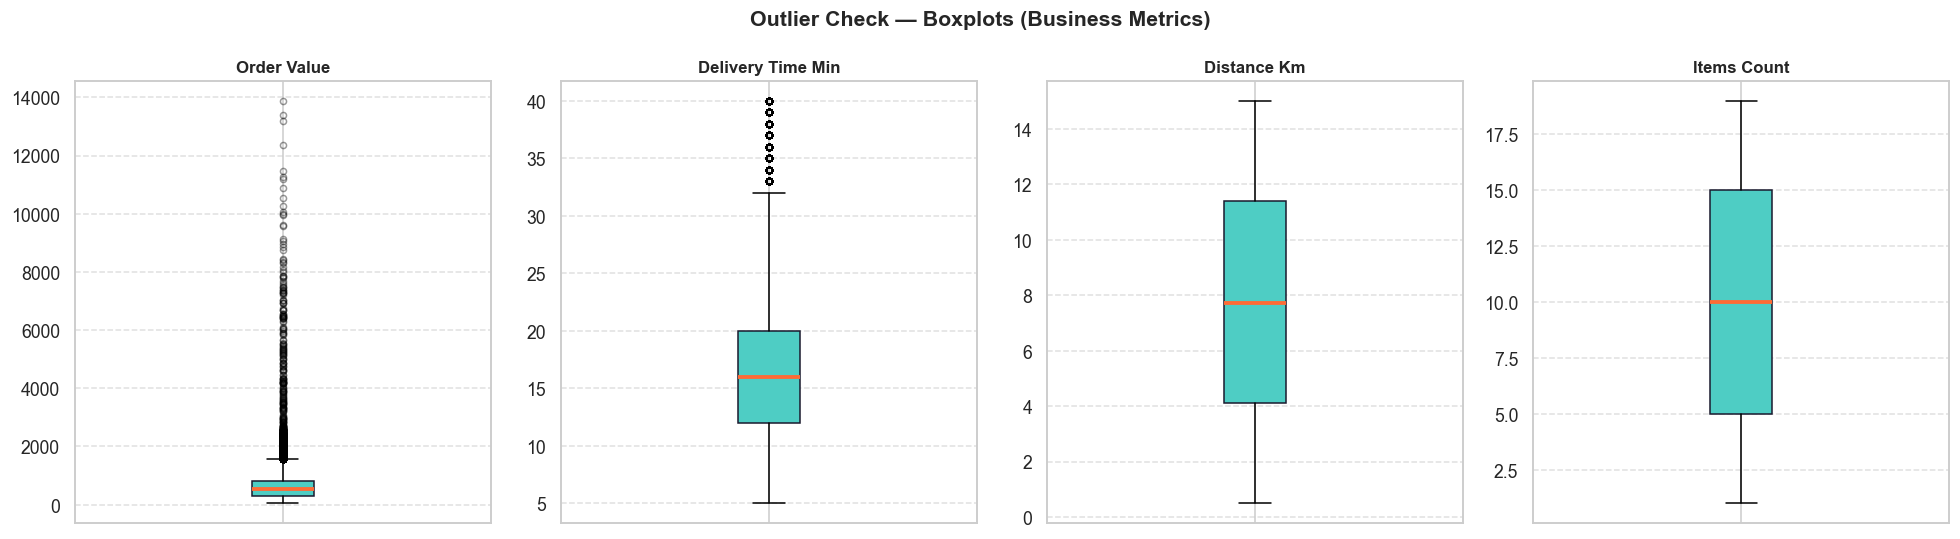

In [13]:
# ── Boxplot visualisation ────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Outlier Check — Boxplots (Business Metrics)", fontweight = 'bold', fontsize = 14)

for ax, col in zip(axs, outlier_cols):
    ax.boxplot(df[col].dropna(), vert = True, patch_artist=True,
               boxprops=dict(facecolor='#4ECDC4', color='#1a1a2e'), 
               medianprops=dict(color='#FF6B35', linewidth=2.5), 
               flierprops=dict(marker='o', color='red', markersize=4, alpha=0.4))
    ax.set_title(col.replace('_', ' '), fontweight='bold', fontsize=11)
    ax.set_xticklabels([])
    ax.grid(linestyle = '--', alpha = 0.6, axis = 'y')

plt.tight_layout()
plt.savefig(PLOTS_DIR/'fig_04_outlier_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# ── Remove outliers & save logs ──────────────────────────────────────────────
all_outlier_idx = set()

for col in outlier_cols:
    lower = iqr_fences[col]['lower']
    upper = iqr_fences[col]['upper']
    mask  = (df[col] < lower) | (df[col] > upper)
    all_outlier_idx.update(df[mask].index.tolist())

# Preserved outlier rows in memory for the bulk-order analysis in Section 7
df_outliers = df.loc[list(all_outlier_idx)].copy()
df_outliers.to_csv(DATA_OUTLIERS, index=True)

df_clean = df.drop(index=list(all_outlier_idx)).reset_index(drop=True)

print(f'Original rows : {len(df):,}')
print(f'Outlier rows  : {len(all_outlier_idx):,}  ({len(all_outlier_idx) / len(df) * 100:.1f}%)')
print(f'Clean rows    : {len(df_clean):,}')

Original rows : 965,000
Outlier rows  : 24,522  (2.5%)
Clean rows    : 940,478


In [15]:
# ── Before vs After impact of outlier removal ────────────────────────────────────────────
impact_rows = []

for col in outlier_cols:
    mean_before = df[col].mean()
    mean_after  = df_clean[col].mean()
    shift       = (mean_after - mean_before) / mean_before * 100
    impact_rows.append({
        'Column' : col,
        'Mean Before' : round(mean_before, 2),
        'Mean After'  : round(mean_after, 2),
        'Mean Shift'  : f'{shift:+.1f}%',
        'Std Before'  : round(df[col].std(), 2),
        'Std After'   : round(df_clean[col].std(), 2),
        'Impact'      : 'Low' if abs(shift) < 2 else ('Moderate' if abs(shift) < 10 else 'High')
    })

print('Before vs After — Impact of Outlier Removal:')
display(pd.DataFrame(impact_rows))

Before vs After — Impact of Outlier Removal:


,Column,Mean Before,Mean After,Mean Shift,Std Before,Std After,Impact
0,Order_Value,571.54,555.80,-2.8%,382.26,348.40,Moderate
1,Delivery_Time_Min,16.46,16.27,-1.1%,6.27,5.99,Low
2,Distance_Km,7.75,7.71,-0.5%,4.19,4.18,Low
3,Items_Count,10.00,10.00,+0.0%,5.48,5.48,Low


> **Interpretation:** `Order_Value` shows ~2.8% mean shift after outlier removal, indicating the flagged rows were indeed high-value anomalies. `Distance_Km` and `Items_Count` shifts are minimal, indicating those outliers were measurement noise rather than systematic patterns. All removed rows are preserved in `df_outliers` for the bulk-order analysis in Section 7.

---
## 5. Exploratory Data Analysis

I worked with the cleaned dataset. The working variable `df` is reassigned to `df_clean` here for all downstream analysis.

In [16]:
# ── Promote df_clean to df for downstream analysis ───────────────────────────
df_clean.to_csv(DATA_CLEAN, index=False)
df = df_clean.copy()
df['Order_ID'] = df['Order_ID'].astype(str)

print(f'Clean dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.describe().round(2)

Clean dataset shape: 940,478 rows × 13 columns


,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,940478.00,940478.0,940478.00,940478.00,940478.00,940478.00,940478.00,940478.00
mean,38.47,555.8,16.27,7.71,10.00,3.04,0.39,3.80
std,12.12,348.4,5.99,4.18,5.48,1.20,0.49,0.72
min,18.00,50.0,5.00,0.50,1.00,1.00,0.00,2.00
25%,28.00,286.0,12.00,4.10,5.00,2.00,0.00,3.00
50%,38.00,527.0,16.00,7.70,10.00,3.00,0.00,4.00
75%,49.00,785.0,20.00,11.30,15.00,4.00,1.00,4.00
max,59.00,1558.0,32.00,15.00,19.00,5.00,1.00,5.00


### 5.1 Revenue by Platform

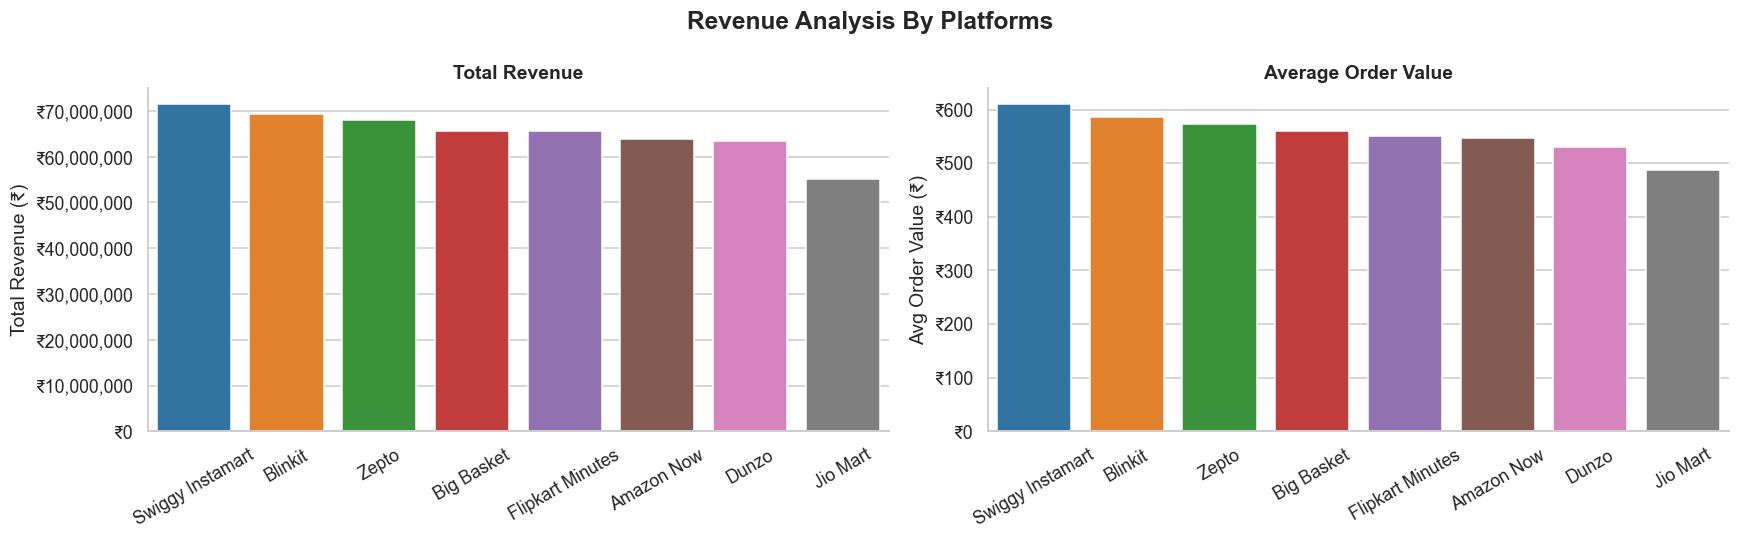

In [17]:
total_revenue = (df.groupby('Company')['Order_Value']
                 .sum()
                 .sort_values(ascending = False)
                 .reset_index()
                 .rename(columns = {'Order_Value': 'Total_Revenue'}))

avg_order_value = (df.groupby('Company')['Order_Value']
                   .mean()
                   .sort_values(ascending = False)
                   .reset_index()
                   .rename(columns = {'Order_Value':'Avg_Order_Value'}))

fig, axs = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Revenue Analysis By Platforms", fontsize=16, fontweight='bold')

# Total Revenue
sns.barplot(data=total_revenue, x='Company', y='Total_Revenue', 
            hue='Company', ax=axs[0], palette='tab10', legend=False)
axs[0].set_title('Total Revenue', fontweight='bold')
axs[0].set_ylabel('Total Revenue (₹)')
axs[0].set_xlabel('')
axs[0].yaxis.set_major_formatter(rupee_fmt)
axs[0].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Average Order Value
sns.barplot(data=avg_order_value, x='Company', y='Avg_Order_Value', 
            hue='Company', ax=axs[1], palette='tab10', legend=False)
axs[1].set_title('Average Order Value', fontweight='bold')
axs[1].set_ylabel('Avg Order Value (₹)')
axs[1].set_xlabel('')
axs[1].yaxis.set_major_formatter(rupee_fmt)
axs[1].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR/'fig_05_1_revenue_by_platform.png', dpi=120, bbox_inches='tight')
plt.show() 

**Finding:** `Swiggy Instamart` leads total revenue. The gap among the top 7 platforms is **~11%**, reflecting a highly competitive market where no single player has a dominant revenue moat. Including `Jio Mart` extends the gap to **~23%**, indicating Jio Mart is not a direct competitor in this segment. Swiggy Instamart also leads in average order value, suggesting its customers buy more premium items or larger baskets.

### 5.2 Customer Age Distribution

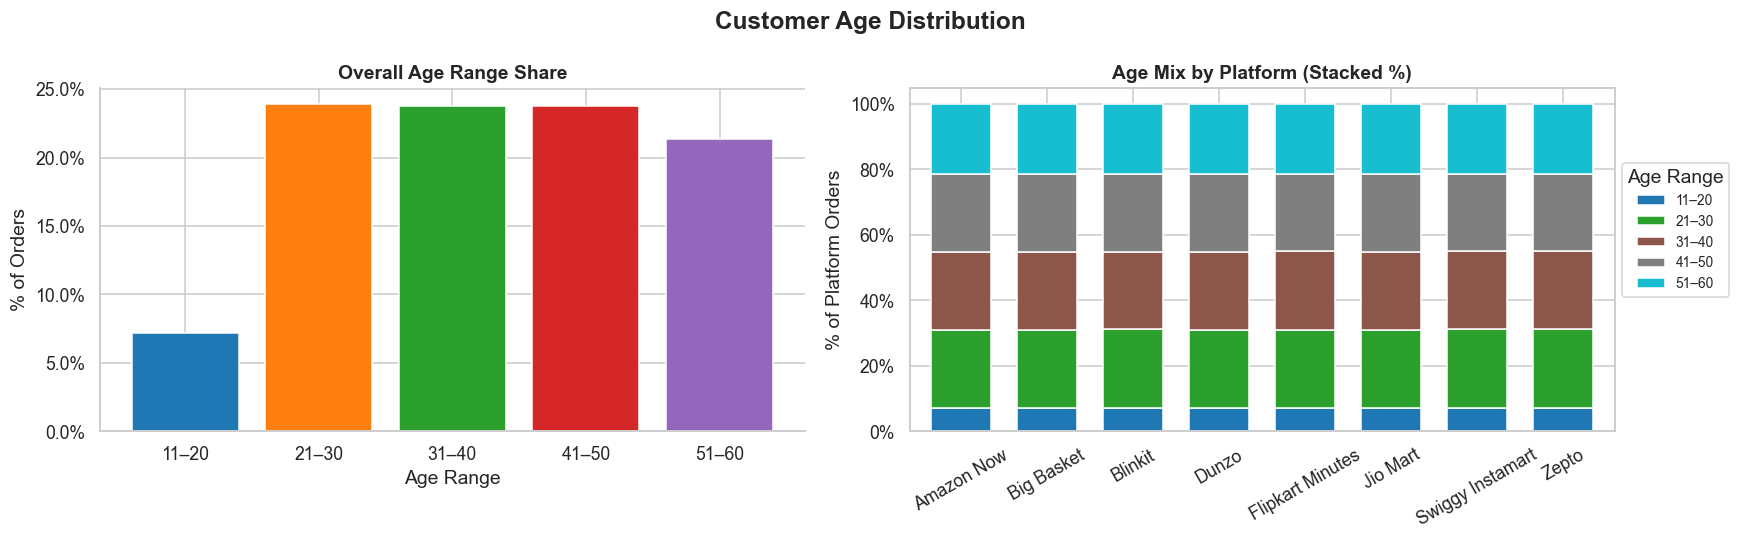

Age Range Distribution:
Age_Range
11–20     7.2
21–30    23.9
31–40    23.8
41–50    23.7
51–60    21.4


In [18]:
# Age bins — using right=True (default) means bins are (left, right]
# Age 10 is excluded from the lowest bin intentionally (min age in data is 11)
df['Age_Range'] = pd.cut(df['Customer_Age'],
                         bins = [10, 20, 30, 40, 50, 60], 
                         labels = ['11–20', '21–30', '31–40', '41–50', '51–60'], 
                         right = True)

age_pct = df['Age_Range'].value_counts(normalize = True).sort_index() * 100

fig, axs = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Customer Age Distribution", fontsize = 16, fontweight = 'bold')

# Overall age share
axs[0].bar(age_pct.index.astype(str), age_pct.values,
            color=sns.color_palette('tab10', len(age_pct)))
axs[0].set_title('Overall Age Range Share', fontweight='bold')
axs[0].set_xlabel('Age Range')
axs[0].set_ylabel('% of Orders')
axs[0].yaxis.set_major_formatter(ticker.PercentFormatter())
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Age Distribution by company (stacked)
age_by_company = df.groupby(['Company', 'Age_Range']).size().unstack(fill_value=0)
age_by_company_pct = age_by_company.div(age_by_company.sum(axis=1), axis=0) * 100
age_by_company_pct.plot(kind = 'bar', stacked=True, ax = axs[1], 
                        colormap='tab10', width=0.7)
axs[1].set_title('Age Mix by Platform (Stacked %)', fontweight='bold')
axs[1].set_xlabel('')
axs[1].set_ylabel('% of Platform Orders')
axs[1].yaxis.set_major_formatter(ticker.PercentFormatter())
axs[1].tick_params(axis='x', rotation=30)
axs[1].legend(title='Age Range', bbox_to_anchor=(1, 0.8), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR/'fig_05_2_age_distribution.png', dpi=120, bbox_inches='tight')

plt.show()

print("Age Range Distribution:")
print(age_pct.round(1).to_string())

**Finding:** The 21–50 bracket accounts for ~71% of all orders — these are working-age adults. The 11–20 segment (7.2%) is significantly underrepresented, likely due to payment method limitations (cash/UPI dependence among teens). All platforms have nearly identical age mixes, suggesting age is a category-level trait rather than a platform differentiator.

### 5.3 Best-Performing Product Categories

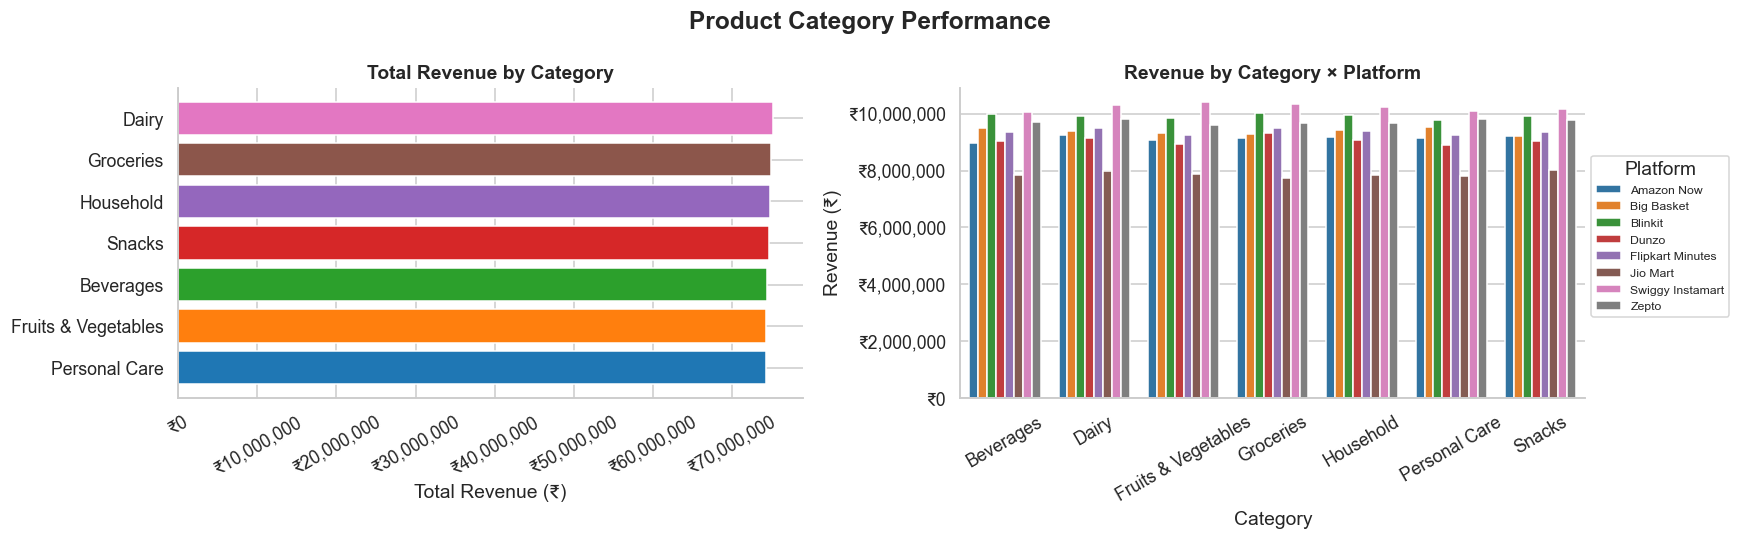

In [19]:
category_perf = (df.groupby(['Company', 'Product_Category'])
                 .agg(
                     Order_Count=('Order_ID',    'count'),
                       Revenue    =('Order_Value', 'sum'),
                       Avg_Revenue=('Order_Value', 'mean'),
                       Avg_Rating =('Customer_Rating', 'mean')
                     )
                 .reset_index()
                 .round(2))

# Overall product category revenue rank
overall_cat = (df.groupby('Product_Category')['Order_Value']
               .sum()
               .sort_values(ascending = True))

fig, axs = plt.subplots(1,2, figsize=(16,5))
fig.suptitle('Product Category Performance', fontsize=16, fontweight='bold')

# Overall revenue by category
colours = sns.color_palette('tab10', len(overall_cat))
axs[0].barh(overall_cat.index, overall_cat.values, color = colours)
axs[0].set_title('Total Revenue by Category', fontweight='bold')
axs[0].set_xlabel('Total Revenue (₹)')
axs[0].xaxis.set_major_formatter(rupee_fmt)
axs[0].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Revenue by category and company
sns.barplot(data=category_perf, x='Product_Category', y='Revenue',
            hue='Company', ax=axs[1], palette='tab10')
axs[1].set_title('Revenue by Category × Platform', fontweight='bold')
axs[1].set_xlabel('Category')
axs[1].set_ylabel('Revenue (₹)')
axs[1].yaxis.set_major_formatter(rupee_fmt)
axs[1].tick_params(axis='x', rotation=30)
axs[1].legend(title='Platform', bbox_to_anchor=(1, 0.8), loc='upper left', fontsize=8)
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR/'fig_05_3_category_performance.png', dpi=120, bbox_inches='tight')

plt.show()

**Finding:** Revenue is distributed fairly evenly across all product categories, with no single category dominating. This reflects Q-Commerce's role as a general convenience platform rather than a specialist retailer. `Swiggy Instamart` leads across most categories, consistent with its overall revenue position.

### 5.4 Geographic Revenue Distribution

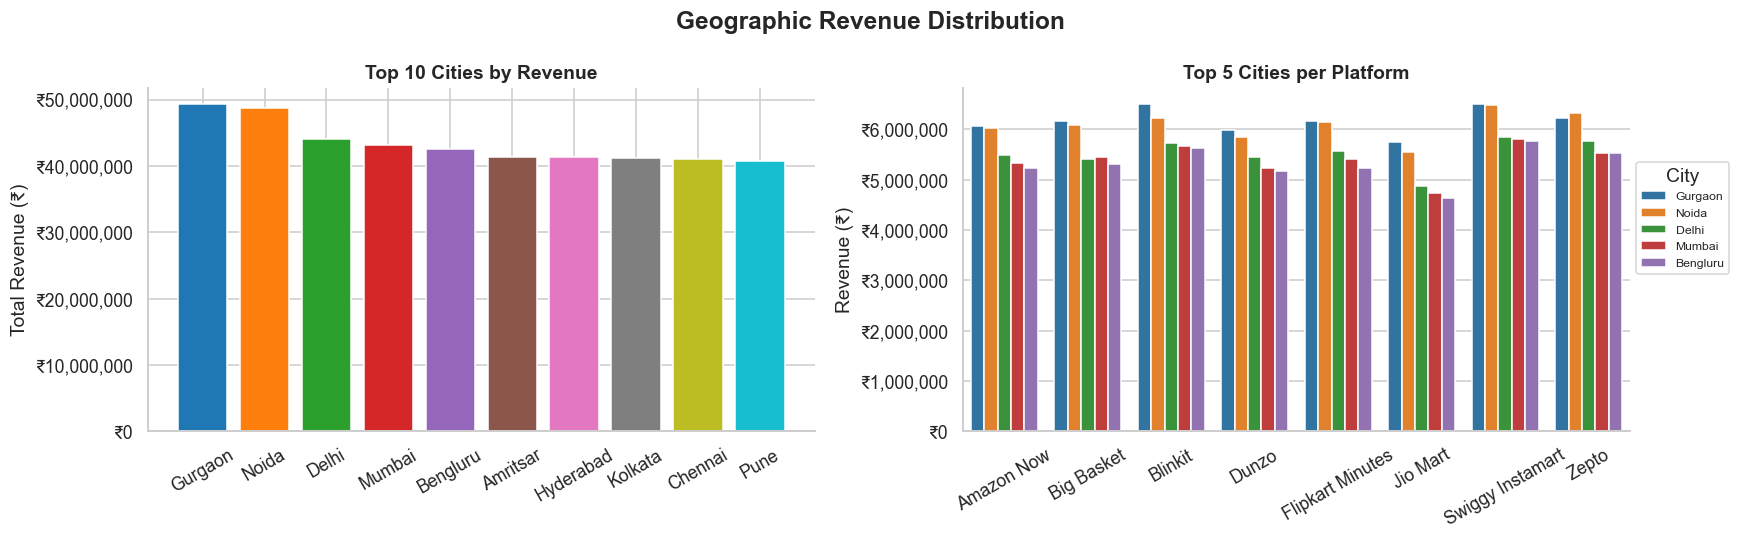

Top 10 Cities by Revenue:


,City,Total_Revenue,Revenue_M
0,Gurgaon,49343528,49.34
1,Noida,48680824,48.68
2,Delhi,44122010,44.12
3,Mumbai,43167054,43.17
4,Bengluru,42488834,42.49
5,Amritsar,41382304,41.38
6,Hyderabad,41282282,41.28
7,Kolkata,41188527,41.19
8,Chennai,41029685,41.03
9,Pune,40796457,40.80


In [20]:
city_revenue = (df.groupby('City')['Order_Value']
                .sum()
                .sort_values(ascending = False)
                .reset_index()
                .rename(columns={'Order_Value': 'Total_Revenue'})
               )

# Top 10 cities (excluding 'Other')
top_cities = city_revenue[city_revenue['City'] != 'Other'].head(10)

fig, axs = plt.subplots(1,2, figsize=(16,5))
fig.suptitle('Geographic Revenue Distribution', fontsize=16, fontweight='bold')

palette = sns.color_palette('tab10', len(top_cities))
axs[0].bar(top_cities['City'], top_cities['Total_Revenue'], color = palette)
axs[0].set_title('Top 10 Cities by Revenue', fontweight='bold')
axs[0].set_ylabel('Total Revenue (₹)')
axs[0].yaxis.set_major_formatter(rupee_fmt)
axs[0].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Revenue concentration — top 5 cities per company
top5_per_company = (df[df['City']!= 'Other']
                    .groupby(['Company', 'City'])['Order_Value']
                    .sum()
                    .groupby(level = 0, group_keys = False)
                    .nlargest(5)
                    .reset_index()
                    .rename(columns={'Order_Value': 'Revenue'}))

sns.barplot(data=top5_per_company, x='Company', y='Revenue',
            hue='City', ax=axs[1], palette='tab10')
axs[1].set_title('Top 5 Cities per Platform', fontweight='bold')
axs[1].set_xlabel('')
axs[1].set_ylabel('Revenue (₹)')
axs[1].yaxis.set_major_formatter(rupee_fmt)
axs[1].tick_params(axis='x', rotation=30)
axs[1].legend(title='City', bbox_to_anchor=(1, 0.8), loc='upper left', fontsize=8)
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR/'fig_05_4_geo_revenue.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 Cities by Revenue:')
display(top_cities.assign(Revenue_M=lambda x: (x['Total_Revenue']/1e6).round(2)))

**Finding:** `Gurgaon` leads revenue among named cities, followed closely by `Noida`. However, the gap between #1 `Gurgaon` and #10 `Pune` is only **~17%**, suggesting that demand is geographically broad rather than concentrated. Platforms cannot afford to focus exclusively on Tier-1 metros.

### 5.5 Delivery Performance Analysis

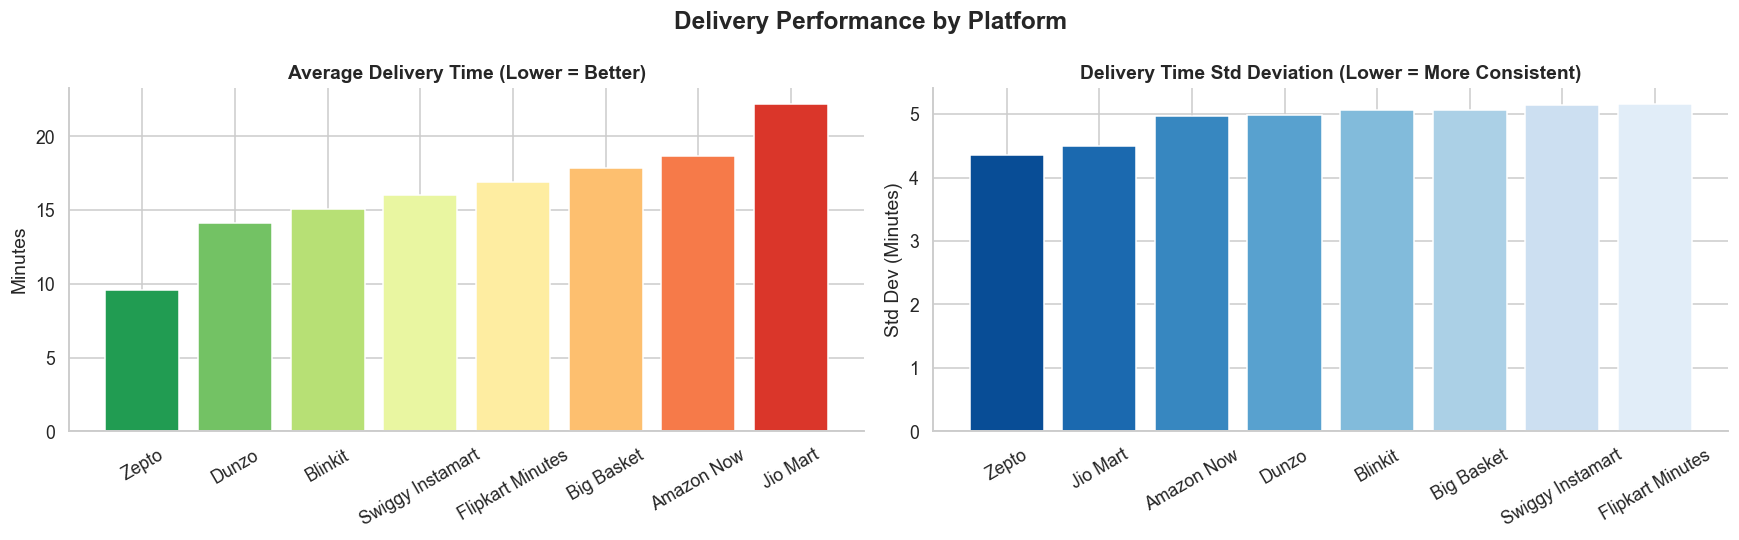

Delivery Time Statistics by Platform:


,Avg_Min,Std_Dev,Median_Min
Company,,,
Zepto,9.59,4.35,9.0
Dunzo,14.14,4.98,14.0
Blinkit,15.09,5.06,15.0
Swiggy Instamart,16.03,5.14,16.0
Flipkart Minutes,16.93,5.16,17.0
Big Basket,17.83,5.06,18.0
Amazon Now,18.68,4.97,19.0
Jio Mart,22.21,4.50,23.0


In [21]:
delivery_stats = (df.groupby('Company')['Delivery_Time_Min']
                  .agg(['mean', 'std', 'median'])
                  .round(2)
                  .rename(columns={'mean': 'Avg_Min', 'std': 'Std_Dev', 'median': 'Median_Min'})
                  .sort_values('Avg_Min'))

fig, axs = plt.subplots(1,2, figsize=(16,5))
fig.suptitle('Delivery Performance by Platform', fontsize=16, fontweight='bold')

# Average delivery time
colours = sns.color_palette('RdYlGn_r', len(delivery_stats))  # red=slow, green=fast
axs[0].bar(delivery_stats.index, delivery_stats['Avg_Min'], color=colours)
axs[0].set_title('Average Delivery Time (Lower = Better)', fontweight='bold')
axs[0].set_xlabel('')
axs[0].set_ylabel('Minutes')
axs[0].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Std deviation — consistency
axs[1].bar(delivery_stats.sort_values('Std_Dev').index, delivery_stats.sort_values('Std_Dev')['Std_Dev'],
            color=sns.color_palette('Blues_r', len(delivery_stats)))
axs[1].set_title('Delivery Time Std Deviation (Lower = More Consistent)', fontweight='bold')
axs[1].set_xlabel('')
axs[1].set_ylabel('Std Dev (Minutes)')
axs[1].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR/'fig_05_5_delivery_performance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Delivery Time Statistics by Platform:')
display(delivery_stats)

Pearson r (original non-null ratings only): -0.0010
P-value: 0.3627
Interpretation: Not significant correlation

Conclusion: r = -0.0010 is near-zero — delivery time does not predict partner ratings.


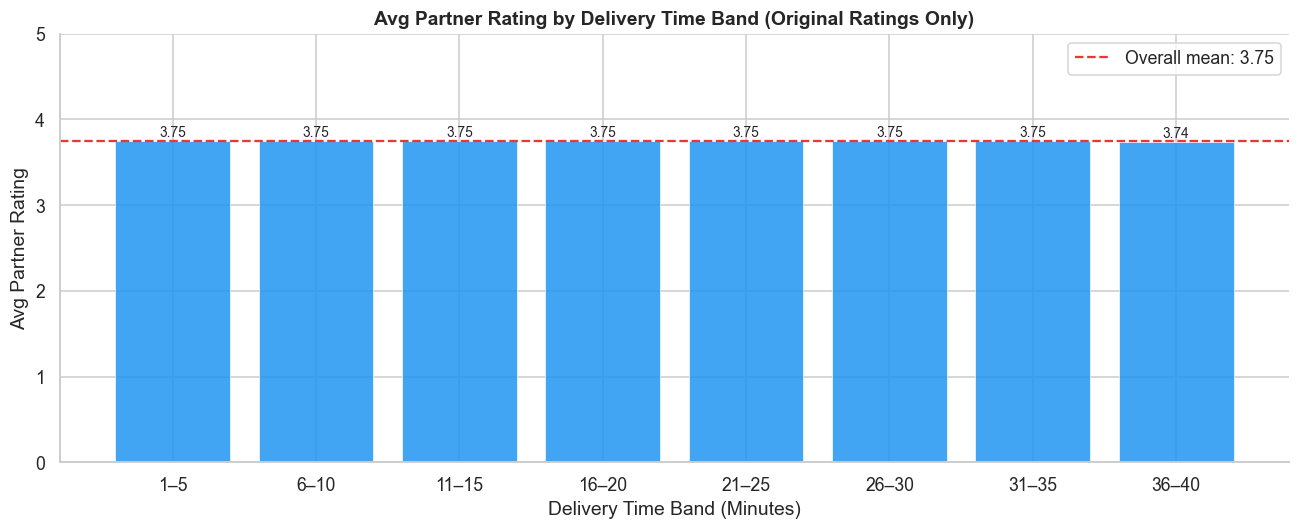

In [22]:
# ── Does delivery time predict partner ratings? ──────────────────────────────
# Important caveat: This analysis uses only originally non-null ratings.
df_raw_ratings = df_raw.dropna(subset=['Delivery_Partner_Rating']).copy()

r, p = stats.pearsonr(df_raw_ratings['Delivery_Time_Min'],
                      df_raw_ratings['Delivery_Partner_Rating'])

print(f'Pearson r (original non-null ratings only): {r:.4f}')
print(f'P-value: {p:.4f}')
print(f'Interpretation: {"Statistically significant" if p < 0.05 else "Not significant"} correlation')
print(f'\nConclusion: r = {r:.4f} is near-zero — delivery time does not predict partner ratings.')

# ── Bin delivery time into 5-minute bands ───────────────
df_raw_ratings['Time_Band'] = pd.cut(
    df_raw_ratings['Delivery_Time_Min'],
    bins=[0, 5, 10, 15, 20, 25, 30, 35, 40],
    labels=['1–5', '6–10', '11–15', '16–20', '21–25', '26–30', '31–35', '36–40']
)

band_avg = (df_raw_ratings.groupby('Time_Band', observed=True)['Delivery_Partner_Rating']
            .mean()
            .reset_index())

overall_mean = df_raw_ratings['Delivery_Partner_Rating'].mean()

# Visual Representation
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(band_avg['Time_Band'], band_avg['Delivery_Partner_Rating'],
       color='#2196F3', edgecolor='white', linewidth=0.5, alpha=0.85)

ax.axhline(overall_mean, color='#E53935', linewidth=1.5,
           linestyle='--', label=f'Overall mean: {overall_mean:.2f}')

ax.set_title('Avg Partner Rating by Delivery Time Band (Original Ratings Only)',
             fontweight='bold')
ax.set_xlabel('Delivery Time Band (Minutes)')
ax.set_ylabel('Avg Partner Rating')
ax.set_ylim(0, 5)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate each bar with its value
for idx, row in band_avg.iterrows():
    ax.text(idx, row['Delivery_Partner_Rating'] + 0.05,
            f'{row["Delivery_Partner_Rating"]:.2f}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fig_05_5b_rating_vs_time.png', dpi=120, bbox_inches='tight')
plt.show()

**Finding:** Zepto is the clear delivery time leader. Delivery consistency (std deviation) is remarkably uniform across platforms (~5 minutes), suggesting the whole industry operates under similar SLA constraints. The near-zero correlation between delivery time and partner ratings indicates customers rate delivery partners on factors beyond speed (courtesy, packaging condition, etc.).

### 5.6 Discount Impact on Order Value
**Hypothesis:** Do discounted orders drive higher average order value?

In [23]:
discount = df[df['Discount_Applied'] == 1]['Order_Value']
no_discount = df[df['Discount_Applied'] == 0]['Order_Value']

# Mann-Whitney U test (non-parametric — order value is right-skewed)
stat, p = mannwhitneyu(discount, no_discount, alternative='greater')

AVG_DISC    = discount.mean()
AVG_NO_DISC = no_discount.mean()
lift = (AVG_DISC - AVG_NO_DISC) / AVG_NO_DISC * 100
LIFT_PCT    = lift

print('Discount Impact — Statistical Test')
print(f'{"─" * 50}')
print(f'Avg Order Value — Discounted   : ₹{AVG_DISC:.0f}')
print(f'Avg Order Value — No Discount  : ₹{AVG_NO_DISC:.0f}')
print(f'Revenue Lift from Discounts    : +{LIFT_PCT:.1f}%')
print(f'Mann-Whitney U statistic       : {stat:.2f}')
print(f'P-value                        : {p:.4e}')
print(f'Conclusion: {"Statistically significant — discounts are associated with higher order values" if p < 0.05 else "Not significant"}')

Discount Impact — Statistical Test
──────────────────────────────────────────────────
Avg Order Value — Discounted   : ₹677
Avg Order Value — No Discount  : ₹477
Revenue Lift from Discounts    : +41.8%
Mann-Whitney U statistic       : 136763501921.50
P-value                        : 0.0000e+00
Conclusion: Statistically significant — discounts are associated with higher order values


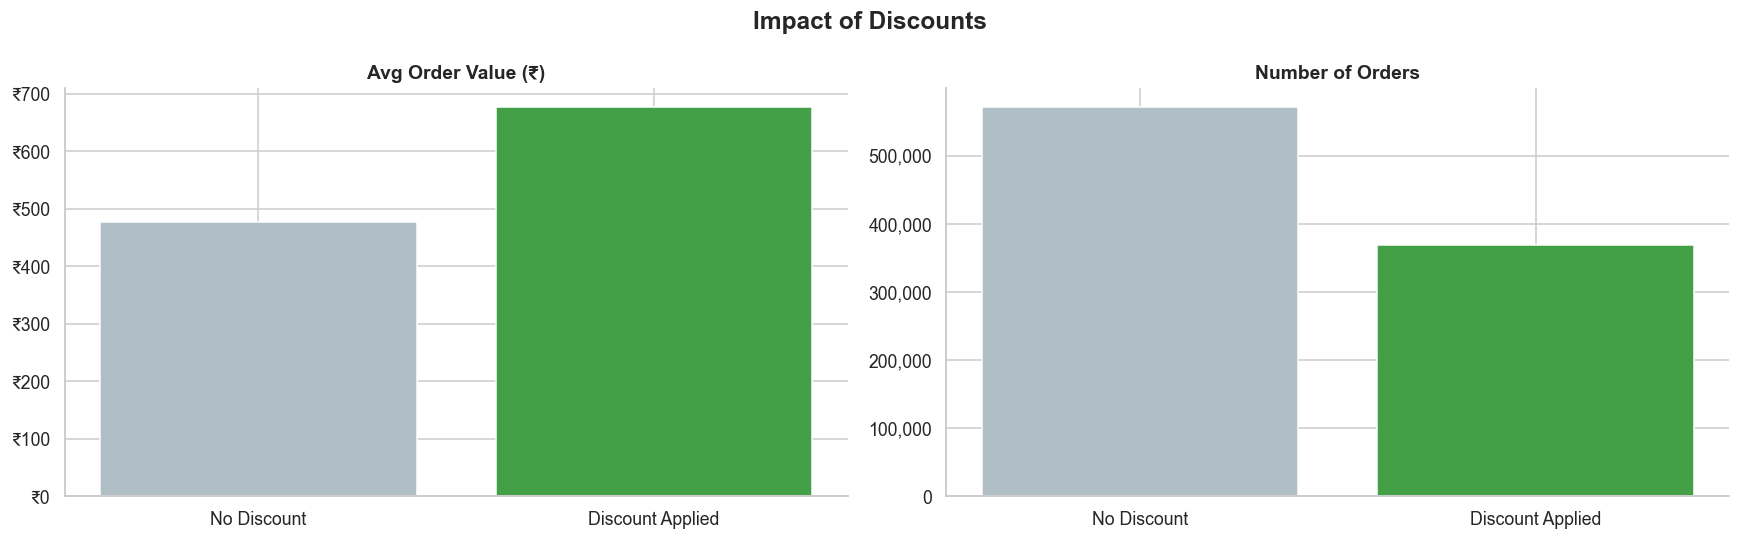

In [24]:
discount_summary = df.groupby('Discount_Applied').agg(
    Avg_Order_Value = ('Order_Value', 'mean'), 
    Total_Items     = ('Items_Count', 'sum'), 
    Order_Count     = ('Order_ID', 'count')
).reset_index()
discount_summary['Discount_Applied'] = discount_summary['Discount_Applied'].map({0: 'No Discount', 1: 'Discount Applied'})

fig, axs = plt.subplots(1,2, figsize=(16,5))
fig.suptitle('Impact of Discounts', fontsize=16, fontweight='bold')

colours = ['#B0BEC5', '#43A047']

axs[0].bar(discount_summary['Discount_Applied'], discount_summary['Avg_Order_Value'], color=colours)
axs[0].set_title('Avg Order Value (₹)', fontweight='bold')
axs[0].yaxis.set_major_formatter(rupee_fmt)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

axs[1].bar(discount_summary['Discount_Applied'], discount_summary['Order_Count'], color=colours)
axs[1].set_title('Number of Orders', fontweight='bold')
axs[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR/'fig_05_6_discount_impact.png', dpi=120, bbox_inches='tight')
plt.show()

**Finding (statistically confirmed):** Discounted orders have a **~42% higher average order value**(Mann-Whitney U, p < 0.001). However, only ~39% of orders use discounts — meaning discounts attract customers who were already planning larger purchases, rather than converting small orders into large ones. Platforms should consider targeting high-intent customers with discounts rather than applying them broadly.

---
## 6. Operational Efficiency Score

I ranked platforms on two dimensions: **volume** (total orders), **delivery speed**(km/min).

> **Speed (km/min) = Distance_Km ÷ Delivery_Time_Min**

This metric encodes both distance and time: a platform that covers more ground per minute is genuinely faster regardless of geography.

> **Efficiency Score = Orders_Scaled + Speed_Scaled**

Both dimensions are scaled to [0, 1] via Min-Max normalisation before combining ensuring neither dimension dominates due to unit differences. A higher score means more orders delivered at higher speed. Weights are **equal by choice** — a weighted variant could be parameterised based on business priorities (e.g. weighting speed 2× if SLA compliance is the primary KPI).
Maximum possible score is 2.0.

**Note on zero delivery times:** Any row with `Delivery_Time_Min = 0` is excluded to avoid division by zero.

In [25]:
# ── Step 1: Compute Speed at row level ──────────────────────────────────────
zero_time_rows = (df['Delivery_Time_Min'] == 0).sum()
print(f'Rows with Delivery_Time_Min = 0 (excluded from speed): {zero_time_rows:,}')

# Created a new dataframe for speed calculation
df_speed = df[df['Delivery_Time_Min'] > 0].copy()
df_speed['Speed_km_per_min'] = df_speed['Distance_Km'] / df_speed['Delivery_Time_Min']

print(f'\nSpeed (km/min) — descriptive stats:')
print(df_speed['Speed_km_per_min'].describe().round(4))

print('\nSample rows:')
display(df_speed[['Company', 'Distance_Km', 'Delivery_Time_Min', 'Speed_km_per_min']].head(6).round(3))

Rows with Delivery_Time_Min = 0 (excluded from speed): 0

Speed (km/min) — descriptive stats:
count    940478.0000
mean          0.5180
std           0.3470
min           0.0161
25%           0.2846
50%           0.4733
75%           0.6562
max           3.0000
Name: Speed_km_per_min, dtype: float64

Sample rows:


,Company,Distance_Km,Delivery_Time_Min,Speed_km_per_min
0,Swiggy Instamart,12.0,19,0.632
1,Flipkart Minutes,12.7,20,0.635
2,Swiggy Instamart,6.4,6,1.067
3,Dunzo,2.4,12,0.200
4,Jio Mart,1.2,20,0.060
5,Blinkit,12.5,18,0.694


In [26]:
# ── Step 2: Aggregate to platform level ─────────────────────────────────────
ops = (df_speed.groupby('Company')
       .agg(
           Total_Orders = ('Order_ID', 'count'),
           Avg_Distance_Km = ('Distance_Km', 'mean'),
           Avg_Delivery_Min = ('Delivery_Time_Min', 'mean'), 
           Avg_Speed_km_min = ('Speed_km_per_min', 'mean'))
       .reset_index()
       .round(3))

# ── Step 3: Scale and score ──────────────────────────────────────────────────
scaler = MinMaxScaler()
ops[['Orders_Scaled', 'Speed_Scaled']] = scaler.fit_transform(ops[['Total_Orders', 'Avg_Speed_km_min']])

ops['Efficiency_Score'] = ops['Orders_Scaled'] + ops['Speed_Scaled']
ops = ops.sort_values('Efficiency_Score', ascending = False).reset_index(drop=True)
ops['Rank'] = ops.index + 1

print('Operational Efficiency Ranking (Speed-Based):')
display(ops[['Rank', 'Company', 'Total_Orders', 'Avg_Distance_Km', 'Avg_Delivery_Min', 'Avg_Speed_km_min', 'Efficiency_Score']])

Operational Efficiency Ranking (Speed-Based):


,Rank,Company,Total_Orders,Avg_Distance_Km,Avg_Delivery_Min,Avg_Speed_km_min,Efficiency_Score
0,1,Zepto,118724,7.739,9.591,0.839,1.882277
1,2,Dunzo,119458,7.756,14.136,0.578,1.476954
2,3,Blinkit,118489,7.745,15.086,0.538,1.241381
3,4,Flipkart Minutes,119194,7.739,16.935,0.474,1.226195
4,5,Swiggy Instamart,117143,7.743,16.031,0.504,0.957366
5,6,Big Basket,117350,7.686,17.829,0.443,0.868321
6,7,Amazon Now,116897,7.650,18.676,0.418,0.745567
7,8,Jio Mart,113223,7.614,22.208,0.340,0.000000


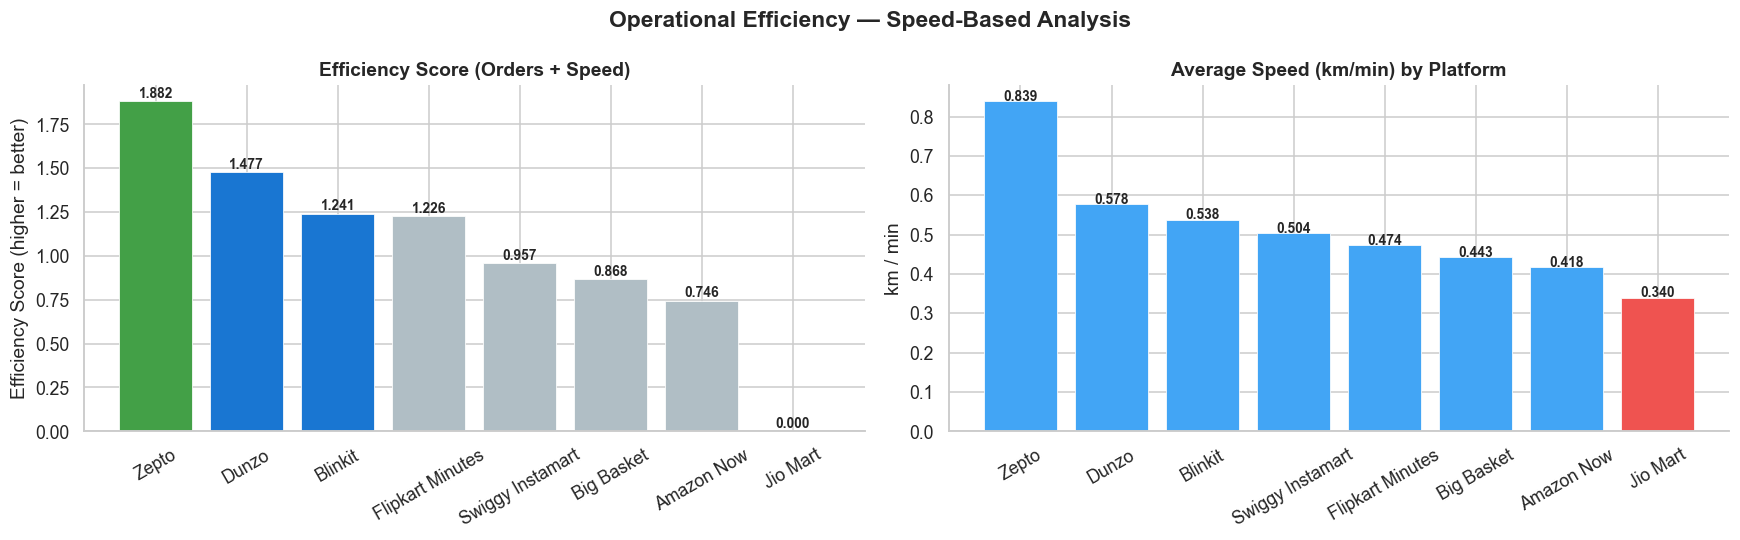

In [27]:
# ── Bar chart — efficiency ranking ──────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Operational Efficiency — Speed-Based Analysis', fontsize=15, fontweight='bold')

# Efficiency score ranking
bar_colours = ['#43A047' if i == 0 else '#1976D2' if i < 3 else '#B0BEC5' for i in range(len(ops))]
axs[0].bar(ops['Company'], ops['Efficiency_Score'], color=bar_colours, edgecolor='white', linewidth=0.5)
axs[0].set_title('Efficiency Score (Orders + Speed)', fontweight='bold')
axs[0].set_xlabel('')
axs[0].set_ylabel('Efficiency Score (higher = better)')
axs[0].tick_params(axis='x', rotation=30)
axs[0].axhline(0, color='grey', linewidth=0.8, linestyle='--')
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)
for idx, row in ops.iterrows():
    axs[0].text(idx, row['Efficiency_Score'] + 0.02,
                 f"{row['Efficiency_Score']:.3f}", ha='center', fontsize=9, fontweight='bold')

# Average speed by platform
speed_sorted = ops.sort_values('Avg_Speed_km_min', ascending=False)
speed_colours = ['#EF5350' if i == len(speed_sorted)-1 else '#42A5F5' for i in range(len(speed_sorted))]
axs[1].bar(speed_sorted['Company'], speed_sorted['Avg_Speed_km_min'],
            color=speed_colours, edgecolor='white', linewidth=0.5)
axs[1].set_title('Average Speed (km/min) by Platform', fontweight='bold')
axs[1].set_xlabel('')
axs[1].set_ylabel('km / min')
axs[1].tick_params(axis='x', rotation=30)
for spine in ['top', 'right']: axs[1].spines[spine].set_visible(False)
for idx, (_, row) in enumerate(speed_sorted.iterrows()):
    axs[1].text(idx, row['Avg_Speed_km_min'] + 0.001,
                 f"{row['Avg_Speed_km_min']:.3f}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR/'fig_06_efficiency_score.png', dpi=120, bbox_inches='tight')
plt.show()

> **Note on Jio Mart's score of 0.000:** This is a property of `Min-Max normalisation`, which maps the minimum value in any column to exactly 0. Jio Mart ranked last on both total orders and average delivery speed in this dataset, so both its scaled components equal 0. The score does not mean zero operational activity — it means Jio Mart sits at the bottom of the peer group on both dimensions simultaneously. All other platforms scored above zero because they ranked higher on at least one dimension.

In [28]:
# ── Interactive bubble chart — Orders vs Speed ──────────────────────────────
ops['Bubble_Size'] = ops['Efficiency_Score'] - ops['Efficiency_Score'].min() + 0.2

fig = px.scatter(ops, x='Total_Orders', y='Avg_Speed_km_min', size='Bubble_Size',
                 color='Company', text='Company',
                 title='Operational Efficiency: Volume vs Delivery Speed (km/min)',
                 hover_data={
                     'Total_Orders'    : True,
                     'Avg_Speed_km_min': ':.4f',
                     'Avg_Delivery_Min': ':.2f',
                     'Avg_Distance_Km' : ':.2f',
                     'Efficiency_Score': ':.3f'
                 },
                 size_max=55)

fig.update_traces(textposition='middle center')
fig.update_layout(
    xaxis_title='Total Orders (Higher = Better)',
    yaxis_title='Avg Speed — km/min (Higher = Better)',
    title_x=0.5,
    template='plotly_dark',
    height=620
)
fig.show()

**Finding:** `Zepto` ranks first in the efficiency score, driven by its lead in average delivery speed(**~0.839 km/min**) — meaning it covers more ground per delivery minute than any other platform. `Dunzo` and `Blinkit` serve shorter average distances but maintain competitive delivery times, suggesting strong dark store density. `Jio Mart` covers comparable distances to peers but takes significantly longer — pointing to a logistics or routing inefficiency rather than a geography problem.

---
## 7. The Bulk Order Segment (Outlier Deep-Dive)

The rows removed as outliers in section 4 are not errors — they represent a distinct **high-value customer segment**. I retained them in `df_outliers` specifically for this analysis.

In [29]:
# Overview
bulk = df_outliers.copy()
bulk['Order_ID'] = bulk['Order_ID'].astype(str)

print(f'Bulk orders: {len(bulk):,}')
print(f'Avg Order Value  : ₹{bulk["Order_Value"].mean():.0f}  (vs ₹{df["Order_Value"].mean():.0f} in clean data)')
print(f'Avg Delivery Time: {bulk["Delivery_Time_Min"].mean():.1f} min  (vs {df["Delivery_Time_Min"].mean():.1f} min in clean data)')
print(f'Avg Items Count  : {bulk["Items_Count"].mean():.1f}  (vs {df["Items_Count"].mean():.1f} in clean data)')
print(f'Discount Rate    : {bulk["Discount_Applied"].mean()*100:.1f}%  (vs {df["Discount_Applied"].mean()*100:.1f}% in clean data)')

Bulk orders: 24,522
Avg Order Value  : ₹1175  (vs ₹556 in clean data)
Avg Delivery Time: 23.6 min  (vs 16.3 min in clean data)
Avg Items Count  : 10.0  (vs 10.0 in clean data)
Discount Rate    : 72.4%  (vs 39.3% in clean data)


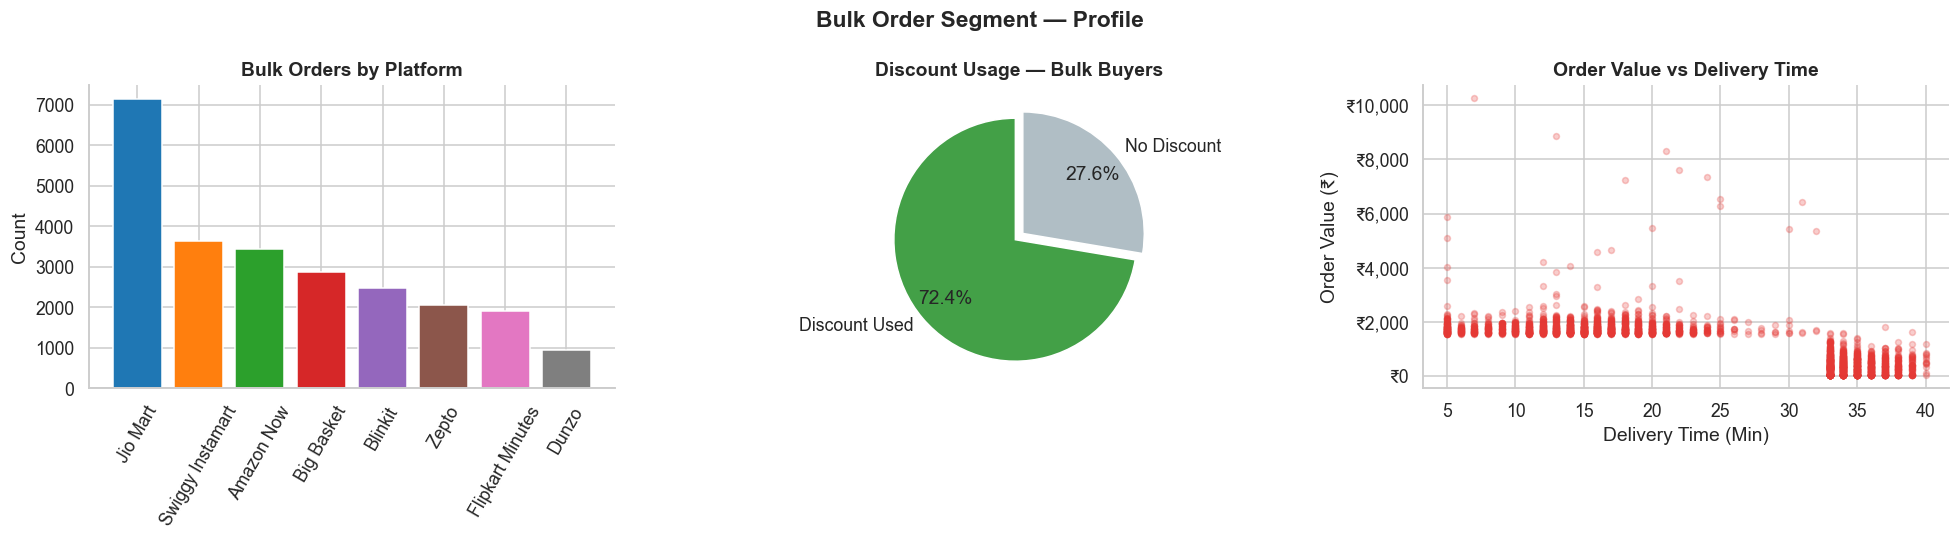

In [30]:
# ── Visualizing the bulk buyers ─────────────────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Bulk Order Segment — Profile', fontsize=15, fontweight='bold')

# Company share of bulk orders
bulk_by_company = bulk['Company'].value_counts()
axs[0].bar(bulk_by_company.index, bulk_by_company.values, color=sns.color_palette('tab10', len(bulk_by_company)))
axs[0].set_title('Bulk Orders by Platform', fontweight='bold')
axs[0].set_ylabel('Count')
axs[0].tick_params(axis='x', rotation=60)
for spine in ['top', 'right']: axs[0].spines[spine].set_visible(False)

# Discount usage in bulk segment
disc_bulk = bulk['Discount_Applied'].value_counts()
colours_d  = ['#43A047', '#B0BEC5']
axs[1].pie(disc_bulk.values, labels=['Discount Used', 'No Discount'],
           autopct='%1.1f%%', startangle=90,
           colors=colours_d, explode=(0.04, 0.04), pctdistance=0.75)
axs[1].set_title('Discount Usage — Bulk Buyers', fontweight='bold')

# Order value vs delivery time (sampled for speed)
sample = bulk.sample(min(3000, len(bulk)), random_state=42)
axs[2].scatter(sample['Delivery_Time_Min'], sample['Order_Value'],
                alpha=0.25, s=15, color='#E53935')
axs[2].set_title('Order Value vs Delivery Time', fontweight='bold')
axs[2].set_xlabel('Delivery Time (Min)')
axs[2].set_ylabel('Order Value (₹)')
axs[2].yaxis.set_major_formatter(rupee_fmt)
for spine in ['top', 'right']: axs[2].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR/'fig_07_bulk_segment.png', dpi=120, bbox_inches='tight')
plt.show()

In [31]:
# Correlation in bulk segment
r_bulk, p_bulk = stats.pearsonr(bulk['Order_Value'], bulk['Delivery_Time_Min'])
print('Bulk Segment — Pearson Correlation: Order Value vs Delivery Time')
print(f'  r = {r_bulk:.4f}')
print(f'  p = {p_bulk:.4e}')
print(f'  n = {len(bulk):,}')
print()
print('Bulk orders by platform:')
display(bulk.groupby('Company').agg(
    Bulk_Orders    =('Order_ID',          'count'),
    Avg_Value      =('Order_Value',       'mean'),
    Avg_Delivery   =('Delivery_Time_Min', 'mean'),
    Discount_Rate  =('Discount_Applied',  'mean')
).reset_index().round(2).sort_values('Avg_Value', ascending=False))

Bulk Segment — Pearson Correlation: Order Value vs Delivery Time
  r = -0.7716
  p = 0.0000e+00
  n = 24,522

Bulk orders by platform:


,Company,Bulk_Orders,Avg_Value,Avg_Delivery,Discount_Rate
3,Dunzo,959,1810.17,13.15,0.98
7,Zepto,2071,1804.12,8.63,0.97
2,Blinkit,2488,1794.62,14.26,0.97
6,Swiggy Instamart,3642,1777.04,15.87,0.94
4,Flipkart Minutes,1912,1408.30,21.22,0.82
1,Big Basket,2869,1224.45,24.16,0.75
0,Amazon Now,3440,915.89,28.01,0.62
5,Jio Mart,7141,428.16,34.92,0.43


In [32]:
# verify correlation between order value and delivery time
if abs(r_bulk) < 0.1:
    strength = 'negligible'
elif abs(r_bulk) < 0.3:
    strength = 'weak'
elif abs(r_bulk) < 0.5:
    strength = 'moderate'
else:
    strength = 'strong'

direction = 'negative' if r_bulk < 0 else 'positive'
sig       = 'statistically significant' if p_bulk < 0.05 else 'not statistically significant'

print(f'Interpretation: {strength} {direction} correlation, {sig} at α = 0.05')
print()
print('Note: A negative r means higher-value orders tend to arrive faster in this segment.')
print('Whether this reflects priority handling or a confound (e.g. location proximity)')
print('cannot be determined from this dataset alone.')

Interpretation: strong negative correlation, statistically significant at α = 0.05

Note: A negative r means higher-value orders tend to arrive faster in this segment.
Whether this reflects priority handling or a confound (e.g. location proximity)
cannot be determined from this dataset alone.


**Finding:** Bulk buyers average **₹1,176 per order — 2.1× the standard customer average of ~₹556**. Critically, **~72.4% apply discounts** versus 39.3% in the main dataset, confirming that bulk buyers are a structurally discount-dependent segment. A Pearson correlation of r ≈ −0.77 between order value and delivery time exists within this segment — higher-value orders tend to arrive faster. Whether this reflects operational prioritisation or simply that high-value orders are placed in locations closer to dark stores cannot be determined from this dataset alone and would require order-routing data to confirm.

---
## 8. Correlation Matrix — Numeric Features

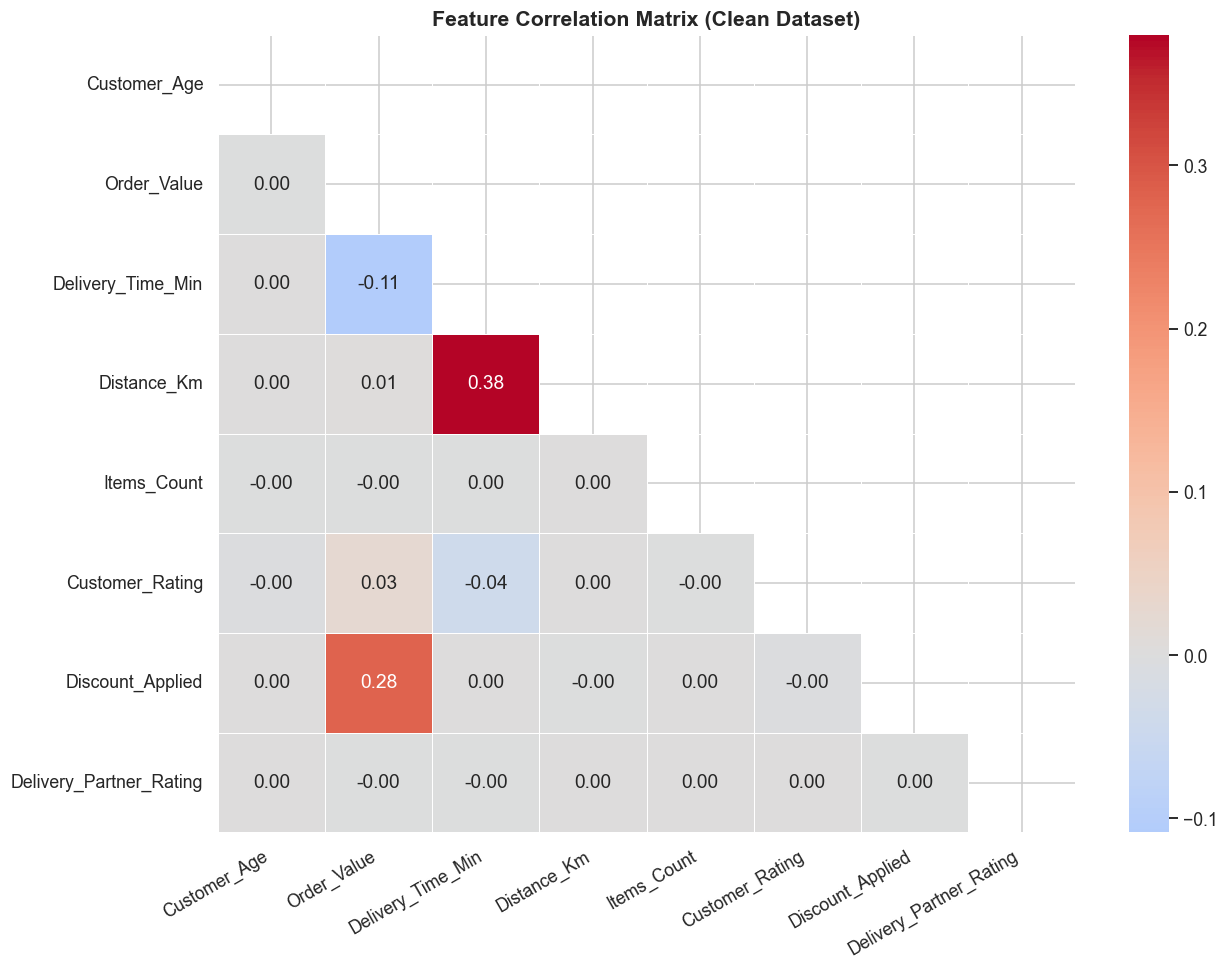

Note: Customer_Rating and Delivery_Partner_Rating were largely imputed by group mean/median,
which artificially suppresses their correlations with other features.


In [33]:
corr_matrix = df.corr(numeric_only=True)
upp_tria = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle only

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            mask=upp_tria,
            cmap='coolwarm', center=0,
            linewidths=0.5,
            ax=ax)
ax.set_title('Feature Correlation Matrix (Clean Dataset)', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(PLOTS_DIR/'fig_08_correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Note: Customer_Rating and Delivery_Partner_Rating were largely imputed by group mean/median,") 
print(f"which artificially suppresses their correlations with other features.")

---
## 9. Conclusions & Business Recommendations

### Findings 

Each finding is corresponded to section under the Exploratory Data Analysis section.

**1. Revenue — A Hyper-Competitive Market With No Clear Winner**
> No platform holds a sustainable revenue moat. The top seven platforms are within 11% of each other, indicating the competition is decided on speed, reliability and customer experience.
> **Jio Mart** sits outside this cluster with a total revenue gap of 23% from its leader suggesting it is either in an early penetration phase or failing to capture the high-velocity urban segment. *[Section:5.1]*

**2. Demographics — The Category Defines The Customer**
> All eight platforms show virtually identical age distributions. Demographics are a category-level characteristic of Q-Commerce, not a differentiator any platform can easily exploit. Attempts to differentiate on customer demographics are likely to fail because the demographic base is identical across all platforms.
> Competitive differention must come from product range depth, loyalty and speed — not from targeting age profiles. *[Section:5.2]*

**3. Product Categories — Broad Category, No Dominant Category**
> No single category generates a disproportionate share of revenue. The product distribution reflects the fundamental value proposition of Q-Commerce: it is a general-purpose convenience store rather than a specialist retailer. *[Section:5.3]*

**4. Geography — Demand Is Nationwide, Not Metro-concentrated**
> The gap between the top city(Gurgaon) and the tenth city(Pune) is approximately 17%. This narrow gap confirms demand is geographically broad. Platforms should avoid "flagship" city focus. They should instead increase dark-store density in the 11th to 20th ranked cities where competition is currently lower but demand potential is proven. *[Section:5.4]*

**5. Delivery Performance — Zepto Leads; Speed does not drive Ratings**
> Zepto records the highest average delivery speed across all platforms — a genuine comparable operational advantage that accounts for both distance covered and time taken.
> Delivery time standard deviation is approximately five minutes across all platforms, indicating that the whole industry operates under identical real-world constraints(traffic) rather than any platform-specific limitation.
> Pearson correlation between delivery time and partner ratings, computed on original non-imputed values reveals a near-zero relationship. Customers rate delivery partners primarily on interpersonal factors: politeness, packaging integrity and order accuracy. *[Section:5.5]*

**6. Discounts — Attracting High-Intent Buyers**
> Discounted orders carry an average order value approximately 42% higher than non-discounted orders.
> Only ~39% of all orders applied a discount. The elevated order value on discounted orders reflects selection behaviour: customers already planning high-value purchases are more likely to seek out and apply a discount code. The discount rewards an existing intention rather than creating a new one. *[Section:5.6]*

**7. Operational Efficiency Analysis**

> In Q-Commerce, speed is not simply one of the two equally important factors — it is the foundational value proposition of the category. A platform that de-prioritises speed in favour of volume is in effect abandoning the only attribute that distinguishes it from conventional e-commerce. Any operational efficiency framework applied to this category should weight speed at least as heavily as volume and likely more so.

|  **Rank**  |  **Platform**  |  **Score Driver**  |  **Implication**  |
| :--- | :--- |:--- |:--- |
|1| Zepto| Highest delivery speed(km/min) | Speed is the core differentiator: dark store density is likely high |
|2-3| Dunzo,Blinkit | Short distances, fast times | Strong hyperlocal infrastructure; volume is the limiting factor |
|4-6| Swiggy, Big Basket, Flipkart | High volume, average speed | Scale offsets moderate speed; revenue position is defensible |
|7| Amazon Now | Mid-tier on both dimensions| No operational differentiator; brand trust is primary asset |
|8| Jio Mart | Comparable distance, slow delivery | Logistics inefficiency — not a geography problem; correctable |

**8. The Bulk Order/Buyer Segment**

Three characteristics collectively define the bulk buyer as a commercially distinct segment:

- **Order values approximately 2.1 times the standard customer average,** consistent with small business restocking, catering procurement or household bulk purchasing.
- **Discount dependency significantly exceeding the main customer base:** 72% of bulk orders applied a discount versus 39% of standard orders.
- **A statistically significant negative correlation between order value and delivery time** within this segment — higher-value orders are delivered faster suggesting emergent or formal priority handling.
> Bulk buyers are a high-revenue discount-dependent segment currently being served through standard consumer infrastructure. This creates margin leakage without a structured commercial relationship. A formalised B2B or subscription tier — with pre-negotiated pricing, dedicated SLA and account management — would capture this segment's revenue while protecting standard customer pricing integrity.

---
### Strategic Recommendations
Six recommendations drawn from the analytical findings. Each is anchored to a specific finding and scoped to a realistic action.

- **1. Invest in Dark Store Expansion:** Revenue gaps among competitors are narrow and largely explained by operational speed advantages rather than brand strength or product assortment. For non-Zepto platforms, the highest-return investment is dark store density expansion, which directly improves delivery speed, SLA compliance and customer retention. *[Anchored:1,5]*
- **2. Replace Blanket Discounting With Precision Mechanics:** The 42% order value lift on discounted orders is real but driven by selection bias. Platforms should retire open discounts codes in favour of these three targeted mechanics: minimum basket spend thresholds(e.g. 15% off orders above ₹800), cart-abandonment re-engagement offers and loyalty tier rewards for customers with a verified 90-day order history. *[Anchored:6]*
- **3. Formalise a B2B / Bulk Buyer Subscription Tier:** Bulk buyers represent ~2.5% of orders but generate over 2.1 times standard order value. They are currently absorbing open consumer discount codes, creating unnecessary margin leakage. A structured commercial tier with pre-negotiated pricing, dedicated SLA and account management would formalise this relationship and protect standard consumer pricing integrity. *[Anchored:6, Bulk Segment]*
- **4. Implement Geographic Hub-and-Spoke Expansion:** The 17% revenue gap between the top city and the tenth city supports a systematic expansion strategy. Rather than concentrating additional capital in already-saturated metros, platforms should pursue hub-and-spoke expansion: anchor dark stores in NCR and Mumbai, then extend to Bengaluru, Hyderabad, Pune and Chennai where demand density and infrastructure already exists. *[Anchored:4]*
- **5. Invest in Delivery Partner Quality Training:** The near-zero correlation between delivery time and partner ratings confirms that marginal speed improvements at already-fast delivery times will not move satisfaction scores. Investment in partner training programmes — focused on communication, packaging handling and door-step professionalism — will generate measurably greater rating improvements per rupee of operational spend. *[Anchored:5]*
- **6. Diagnose and Resolve Jio Mart's Delivery Latency:** Jio Mart's delivery underperformance relative to peers, despite covering comparable distances is a correctable operational problem. A routing audit, delivery partner deployment density review and dark store-to-demand cluster proximity analysis should be conducted as a priority intervention. Given the parent comapany's resources, this is a prioritisation problem, not a capital one. *[Anchored:5,Efficiency Analysis]*

---

## Limitations & Next Steps

- **No time dimension available** — a timestamp column would enable seasonality, day-of-week, and growth trend analysis, which are critical for a Q-Commerce business.
- **Rating imputation masks signal** — future analyses should source ratings from a system where missingness is tracked at collection time (was the app closed? delivery refused?).
- **Equal-weight efficiency score** — the current scoring weights orders and speed equally; a parameterised version would allow sensitivity analysis.
- **Potential next project:** Build a delivery time prediction model (regression) using `Distance`, `Company`, `City`, and `Items_Count` as features.

---
*Analysis complete. Dataset: ~940K clean orders | ~24.5K bulk orders analysed separately.*

In [34]:
# ── Final dataset state confirmation ─────────────────────────────────────────
print('=' * 55)
print('  FINAL DATASET STATE')
print('=' * 55)
print(f'  Clean rows       : {df.shape[0]:,}')
print(f'  Columns          : {df.shape[1]}')
print(f'  Null values      : {df.isna().sum().sum()}')
print(f'  Duplicate rows   : {df.duplicated().sum():,}')
print(f'  Bulk order rows  : {len(df_outliers):,}  (retained in df_outliers)')
print('=' * 55)
print('\nColumn dtypes:')
print(df.dtypes.to_string())

  FINAL DATASET STATE
  Clean rows       : 940,478
  Columns          : 14
  Null values      : 0
  Duplicate rows   : 0
  Bulk order rows  : 24,522  (retained in df_outliers)

Column dtypes:
Order_ID                        str
Company                         str
City                            str
Customer_Age                  int64
Order_Value                   int64
Delivery_Time_Min             int64
Distance_Km                 float64
Items_Count                   int64
Product_Category                str
Payment_Method                  str
Customer_Rating               int64
Discount_Applied              int64
Delivery_Partner_Rating       int64
Age_Range                  category
